# Workload-Aware Cost Model: OLAP + OLTP Split

## Architecture

| Model | Target workloads | Target variable | Features | Algorithm |
|---|---|---|---|---|
| **OLAP** | job, imdb, tpch, tpcds, ssb | log1p(query latency) | qp_embed + workload_features | RF + **LGBMRanker** + Voting |
| **OLTP** | tpcc, ycsb, twitter, seats | log1p(throughput / latency) | knob_config + hardware + internal_metrics | RF + **LGBMRanker** + Voting |

## Four improvements over previous version

### 1. OLAP / OLTP split
OLAP workloads have rich query-plan variance — the query plan embedding
and operator proportions carry most of the signal. OLTP workloads are
dominated by *configuration* effects (buffer pool, vacuum settings) on
aggregate throughput. Mixing them forces the model to explain two
completely different phenomena with one set of features.

### 2. Log-transform the target
`y = np.log1p(cost)` before training, `np.expm1(pred)` to invert.
Effect: a 10ms difference on a 20ms query gets the same regression
penalty as a 10s difference on a 20s query. Without this, a handful
of large `job` queries dominate the loss and the model ignores the
microsecond OLTP range entirely.

### 3. LGBMRanker (LambdaRank)
Our metric is Spearman — a *ranking* metric. Standard regressors
minimise MSE, which is blind to whether predictions are in the right
order. `LGBMRanker` with `objective='lambdarank'` directly optimises
pairwise ordering within each query group (workload). The `group`
parameter tells LightGBM which rows belong to the same ranking context.

### 4. Retained: WorkloadGroupKFold + permutation importance + combination search

## 0. Imports & LightGBM check

In [62]:
import ast, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from scipy.stats import spearmanr, rankdata
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.model_selection import BaseCrossValidator
from sklearn.decomposition import PCA
from sklearn.base import clone

try:
    import lightgbm as lgb
    from lightgbm import LGBMRanker, LGBMRegressor
    LGBM_OK = True
    print(f'LightGBM {lgb.__version__} available')
except ImportError:
    LGBM_OK = False
    print('LightGBM not installed — run: pip install lightgbm')
    print('Falling back to HistGradientBoostingRegressor for GBM slot')
    from sklearn.ensemble import HistGradientBoostingRegressor

SEED = 42
np.random.seed(SEED)
print('Imports OK')

LightGBM 4.6.0 available
Imports OK


## 1. Load & Merge

In [80]:
df3 = pd.read_csv('df3_semantic_features.csv')
col = pd.read_csv('cost_model_collected.csv')

key_map = {
    'metadata.benchmark':              'benchmark',
    'metadata.db_engine':              'db_engine',
    'metadata.hardware':               'hardware',
    'metadata.hardware_specs.cores':   'cores',
    'metadata.hardware_specs.ram_gb':  'ram_gb',
    'metadata.hardware_specs.threads': 'threads',
    'metadata.workload':               'workload',
}
col_m  = col.rename(columns=key_map)
merged = df3.merge(col_m, how='left', on=list(key_map.values()),
                   suffixes=('', '_col'), validate='m:1', indicator=True)
merged['db_engine_norm'] = (merged['db_engine'].astype(str)
                              .str.strip().str.lower()
                              .replace({'mqsql': 'mysql'}))
da = merged[merged['db_engine_norm'].isin(['postgresql', 'mysql'])].copy()
da = da[da['ram_gb'].isin([32, 64])].copy()
print('Counts:'); print(da['db_engine_norm'].value_counts())
print('\nBenchmarks:'); print(da['benchmark'].value_counts())

Counts:
db_engine_norm
postgresql    13590
mysql          1314
Name: count, dtype: int64

Benchmarks:
benchmark
job              4658
tpch             1212
ssb              1212
tpcds            1212
twitter          1212
ssb_flat_tiny    1212
tpcc             1212
wikipedia        1212
smallbank        1157
ycsb              605
Name: count, dtype: int64


In [81]:
# Quick diagnostic: do all benchmarks have a usable `cost`?
print('\nCost non-null rate by benchmark:')
if 'cost' in da.columns:
    nn = (da.groupby('benchmark')['cost']
            .apply(lambda s: float(s.notna().mean()))
            .sort_values(ascending=False))
    print(nn.to_string())
else:
    print('No `cost` column found in da!')

print('\nColumns that look like cost/throughput/latency:')
cand = [c for c in da.columns if any(k in c.lower() for k in ['cost', 'throughput', 'tps', 'qps', 'latency', 'runtime', 'time_ms', 'time'])]
print(sorted(cand)[:80])
if len(cand) > 80:
    print(f'... ({len(cand)-80} more)')

print('\nMin/median/max of raw cost by benchmark (ignoring NaNs):')
if 'cost' in da.columns:
    summ = (da.groupby('benchmark')['cost']
              .agg(['count','min','median','max'])
              .sort_values('count', ascending=False))
    print(summ.head(20).to_string())


Cost non-null rate by benchmark:
benchmark
job              1.0
smallbank        1.0
ssb              1.0
ssb_flat_tiny    1.0
tpcc             1.0
tpcds            1.0
tpch             1.0
twitter          1.0
wikipedia        1.0
ycsb             1.0

Columns that look like cost/throughput/latency:
['checkpoint_timeout', 'cleanup_cost_delay', 'cleanup_cost_limit', 'cost', 'deadlock_detection_time', 'mask_vacuum_cost_delay', 'mask_vacuum_cost_limit', 'vacuum_cost_page_dirty', 'vacuum_cost_page_hit', 'vacuum_cost_page_miss']

Min/median/max of raw cost by benchmark (ignoring NaNs):
               count           min        median           max
benchmark                                                     
job             4658     -1.000000      1.901352  1.127187e+02
ssb             1212      1.216124      3.147806           inf
ssb_flat_tiny   1212      3.874951      5.320818  1.205690e+01
tpcc            1212  -4279.654986  -1008.967250 -0.000000e+00
tpcds           1212      0.0622

## 2. Data Cleaning + Log-Transform Target

### Why log1p?
Without log-transform, a single 50-second `job` query contributes 50x more
to the MSE loss than a 1-second TPCH query. The model learns to fit the
outliers and gives up on the small-value region entirely.

With `y = log1p(cost)`, the loss landscape is compressed: a 2x cost
ratio is penalised equally whether the baseline is 1ms or 1000ms.
This is especially important for OLTP where costs span microseconds
to milliseconds within the same dataset.

In [82]:
# --- OLTP fix: negative cost encodes throughput ---
# For OLTP benchmarks, stored cost is negative throughput; convert to latency = 1 / (-cost).
oltp_benchmarks = {'tpcc', 'smallbank', 'ycsb', 'twitter', 'wikipedia'}
bench_norm = da['benchmark'].astype(str).str.strip().str.lower()
is_oltp = bench_norm.isin(oltp_benchmarks)

# Ensure numeric + clean inf
da['cost'] = pd.to_numeric(da['cost'], errors='coerce')
da = da.replace([np.inf, -np.inf], np.nan)

oltp_neg_mask = is_oltp & da['cost'].notna() & (da['cost'] < 0)
n_oltp_neg = int(oltp_neg_mask.sum())
if n_oltp_neg > 0:
    throughput = -da.loc[oltp_neg_mask, 'cost'].astype(float)
    positive_tp = throughput > 0
    da.loc[oltp_neg_mask & positive_tp, 'cost'] = 1.0 / throughput[positive_tp]
    da.loc[oltp_neg_mask & ~positive_tp, 'cost'] = np.nan
print(f'OLTP negative-cost rows converted: {n_oltp_neg}')

# Remove sentinel / corrupted values
before = len(da)
da = da[da['cost'].notna()].copy()

neg_left = int((da['cost'] < 0).sum())
if neg_left:
    print(f'Removing {neg_left} remaining negative-cost rows (non-OLTP/corrupted).')
da = da[da['cost'] >= 0].copy()

# IMPORTANT: do not clip the low tail globally (it deletes OLTP near-zero latencies).
# Only clip extreme *high* outliers, per-benchmark, to avoid one benchmark dominating.
def _clip_high_outliers_per_benchmark(g):
    if len(g) < 20:
        return g
    hi = g['cost'].quantile(0.999)
    return g[g['cost'] <= hi]

da = (da.groupby('benchmark', group_keys=False)
        .apply(_clip_high_outliers_per_benchmark)
        .reset_index(drop=True))

after = len(da)
print(f'After cleaning: {after} rows (dropped {before - after})')
print('Benchmarks after cleaning:')
print(da['benchmark'].value_counts())

# Log-transform the target
da['cost_raw']  = da['cost'].copy()
da['cost']      = np.log1p(da['cost_raw'])   # training target

print('\nCost distribution BEFORE log1p:')
print(da.groupby('benchmark')['cost_raw'].describe()[['mean','std','50%','max']].round(6))
print('\nCost distribution AFTER log1p:')
print(da.groupby('benchmark')['cost'].describe()[['mean','std','50%','max']].round(6))

OLTP negative-cost rows converted: 5296
Removing 113 remaining negative-cost rows (non-OLTP/corrupted).
After cleaning: 14767 rows (dropped 137)
Benchmarks after cleaning:
benchmark
job              4540
ssb_flat_tiny    1210
tpcc             1210
tpch             1210
twitter          1210
wikipedia        1210
ssb              1209
tpcds            1209
smallbank        1155
ycsb              604
Name: count, dtype: int64

Cost distribution BEFORE log1p:
                   mean        std       50%        max
benchmark                                              
job            6.558036  10.550415  2.010381  59.611464
smallbank      0.000034   0.000003  0.000034   0.000039
ssb            3.063130   1.258460  3.147570   7.090809
ssb_flat_tiny  5.699124   1.416021  5.307660   9.829149
tpcc           0.000959   0.000612  0.000853   0.002910
tpcds          0.286706   0.206121  0.228987   0.787938
tpch           2.585597   1.554344  2.197362   6.374765
twitter        0.000032   0.000008 

## 3. OLAP / OLTP Split

### Rationale
**OLAP** workloads (JOB, IMDB, TPC-H, TPC-DS, SSB) run complex analytical
queries. Cost variance is driven by *what the query does* — join order,
scan type, aggregation complexity. The query plan embedding and operator
proportions carry this signal.

**OLTP** workloads (TPC-C, YCSB, Twitter, SEATS) run short, repetitive
transactions. Individual query plan embeddings are nearly identical across
rows. The meaningful signal is *how the DB is configured* — buffer pool
size, commit batch size, worker threads — and how that maps to aggregate
throughput.

Edit `OLAP_BENCHMARKS` / `OLTP_BENCHMARKS` if your benchmark names differ.

In [65]:
# Assign based on the actual benchmark names in your data
# Print da['benchmark'].unique() above to verify and adjust these sets
OLAP_BENCHMARKS = {'job', 'imdb', 'tpch', 'tpc-h', 'tpcds', 'tpc-ds', 'ssb',
                    'star_schema_benchmark', 'join_order_benchmark'}
OLTP_BENCHMARKS = {'tpcc', 'smallbank', 'ycsb', 'twitter', 'wikipedia'}

def classify_workload(bench):
    b = str(bench).lower().strip()
    if b in OLAP_BENCHMARKS or any(x in b for x in ['olap','tpch','tpcds','ssb','job','imdb']):
        return 'OLAP'
    if b in OLTP_BENCHMARKS or any(x in b for x in ['oltp','tpcc', 'smallbank', 'ycsb', 'twitter', 'wikipedia']):
        return 'OLTP'
    return 'UNKNOWN'

da['workload_type'] = da['benchmark'].apply(classify_workload)

print('Workload type distribution:')
print(da['workload_type'].value_counts())
print('\nPer benchmark:')
print(da.groupby(['benchmark','workload_type'])['cost'].count().rename('n').reset_index().to_string(index=False))

# Warn if any rows are unclassified
unk = da[da['workload_type']=='UNKNOWN']
if len(unk):
    print(f'\nWARNING: {len(unk)} rows unclassified. Unique benchmarks: {unk["benchmark"].unique()}')
    print('Add these to OLAP_BENCHMARKS or OLTP_BENCHMARKS above.')

olap_df = da[da['workload_type']=='OLAP'].copy()
oltp_df = da[da['workload_type']=='OLTP'].copy()
print(f'\nOLAP rows: {len(olap_df)}   OLTP rows: {len(oltp_df)}')

Workload type distribution:
workload_type
OLAP    9383
OLTP     102
Name: count, dtype: int64

Per benchmark:
    benchmark workload_type    n
          job          OLAP 4537
          ssb          OLAP 1211
ssb_flat_tiny          OLAP 1212
         tpcc          OLTP  102
        tpcds          OLAP 1211
         tpch          OLAP 1212

OLAP rows: 9383   OLTP rows: 102


## 4. Feature Definitions

In [66]:
def present(cols):
    return [c for c in cols if c in da.columns]

HARDWARE = present(['ram_gb', 'cores', 'threads'])

KNOB_CONFIG = present([
    'buffer_pool_size','cache_effective_size','per_query_memory',
    'maintenance_memory','temp_memory','log_buffer_size',
    'log_capacity','log_flush_interval','commit_batch_size','io_parallelism',
    'bgwriter_lru_pages','bgwriter_aggressiveness','mask_bgwriter_aggressiveness','bgwriter_flush_after',
    'checkpoint_timeout','checkpoint_completion_ratio','checkpoint_flush_threshold','mask_checkpoint_flush_threshold',
    'vacuum_cost_page_dirty','vacuum_cost_page_hit','vacuum_cost_page_miss','flush_behavior',
    'cleanup_worker_count','cleanup_interval','cleanup_cost_delay','mask_vacuum_cost_delay',
    'cleanup_cost_limit','mask_vacuum_cost_limit','cleanup_scale_factor','mask_cleanup_scale_factor',
    'cleanup_analyze_scale_factor','mask_cleanup_analyze_scale_factor',
    'cleanup_threshold','mask_cleanup_threshold','cleanup_analyze_threshold','mask_cleanup_analyze_threshold',
    'worker_threads','mask_worker_threads',
    'join_search_limit','from_search_limit',
    'mask_geqo_effort','mask_geqo_pool_size','mask_geqo_generations','mask_geqo_threshold',
    'geqo_random_seed','mask_geqo_random_seed',
    'stats_target','cursor_bias','mask_cursor_bias','deadlock_detection_time',
])

INTERNAL_METRICS = present([
    'collected.internal_metrics.blks_hit','collected.internal_metrics.blks_read',
    'collected.internal_metrics.conflicts',
    'collected.internal_metrics.disk_read_bytes','collected.internal_metrics.disk_read_count',
    'collected.internal_metrics.disk_write_bytes','collected.internal_metrics.disk_write_count',
    'collected.internal_metrics.tup_deleted','collected.internal_metrics.tup_fetched',
    'collected.internal_metrics.tup_inserted','collected.internal_metrics.tup_returned',
    'collected.internal_metrics.tup_updated',
    'collected.internal_metrics.xact_commit','collected.internal_metrics.xact_rollback',
])

WORKLOAD_FEATURES = present([
    'collected.workload_features.avg_predicates_per_query',
    'collected.workload_features.read_count','collected.workload_features.write_count',
    'collected.workload_features.total_statements','collected.workload_features.read_write_ratio',
    'collected.workload_features.operator_proportions.DELETE',
    'collected.workload_features.operator_proportions.INSERT',
    'collected.workload_features.operator_proportions.SELECT',
    'collected.workload_features.operator_proportions.UPDATE',
    'collected.workload_features.operator_proportions.avg_agg',
    'collected.workload_features.operator_proportions.count_agg',
    'collected.workload_features.operator_proportions.group_by',
    'collected.workload_features.operator_proportions.max_agg',
    'collected.workload_features.operator_proportions.min_agg',
    'collected.workload_features.operator_proportions.order_by',
    'collected.workload_features.operator_proportions.sum_agg',
    'collected.workload_features.table_access_frequency.accounts',
    'collected.workload_features.table_access_frequency.added_tweets',
    'collected.workload_features.table_access_frequency.aka_name',
    'collected.workload_features.table_access_frequency.aka_title',
    'collected.workload_features.table_access_frequency.cast_info',
    'collected.workload_features.table_access_frequency.catalog_returns',
    'collected.workload_features.table_access_frequency.catalog_sales',
    'collected.workload_features.table_access_frequency.char_name',
    'collected.workload_features.table_access_frequency.checking',
    'collected.workload_features.table_access_frequency.comp_cast_type',
    'collected.workload_features.table_access_frequency.company_name',
    'collected.workload_features.table_access_frequency.company_type',
    'collected.workload_features.table_access_frequency.complete_cast',
    'collected.workload_features.table_access_frequency.customer',
    'collected.workload_features.table_access_frequency.customer_address',
    'collected.workload_features.table_access_frequency.customer_demographics',
    'collected.workload_features.table_access_frequency.customer_summary',
    'collected.workload_features.table_access_frequency.date_dim',
    'collected.workload_features.table_access_frequency.district',
    'collected.workload_features.table_access_frequency.follows',
    'collected.workload_features.table_access_frequency.history',
    'collected.workload_features.table_access_frequency.household_demographics',
    'collected.workload_features.table_access_frequency.info_type',
    'collected.workload_features.table_access_frequency.inventory',
    'collected.workload_features.table_access_frequency.item',
    'collected.workload_features.table_access_frequency.keyword',
    'collected.workload_features.table_access_frequency.kind_type',
    'collected.workload_features.table_access_frequency.lineitem',
    'collected.workload_features.table_access_frequency.lineorder',
    'collected.workload_features.table_access_frequency.lineorder_flat',
    'collected.workload_features.table_access_frequency.link_type',
    'collected.workload_features.table_access_frequency.logging',
    'collected.workload_features.table_access_frequency.movie_companies',
    'collected.workload_features.table_access_frequency.movie_info',
    'collected.workload_features.table_access_frequency.movie_info_idx',
    'collected.workload_features.table_access_frequency.movie_keyword',
    'collected.workload_features.table_access_frequency.movie_link',
    'collected.workload_features.table_access_frequency.name',
    'collected.workload_features.table_access_frequency.nation',
    'collected.workload_features.table_access_frequency.new_order',
    'collected.workload_features.table_access_frequency.oorder',
    'collected.workload_features.table_access_frequency.order_line',
    'collected.workload_features.table_access_frequency.orders',
    'collected.workload_features.table_access_frequency.page',
    'collected.workload_features.table_access_frequency.part',
    'collected.workload_features.table_access_frequency.partsupp',
    'collected.workload_features.table_access_frequency.person_info',
    'collected.workload_features.table_access_frequency.promotion',
    'collected.workload_features.table_access_frequency.reason',
    'collected.workload_features.table_access_frequency.region',
    'collected.workload_features.table_access_frequency.revision',
    'collected.workload_features.table_access_frequency.role_type',
    'collected.workload_features.table_access_frequency.savings',
    'collected.workload_features.table_access_frequency.stock',
    'collected.workload_features.table_access_frequency.store',
    'collected.workload_features.table_access_frequency.store_returns',
    'collected.workload_features.table_access_frequency.store_sales',
    'collected.workload_features.table_access_frequency.supplier',
    'collected.workload_features.table_access_frequency.text',
    'collected.workload_features.table_access_frequency.title',
    'collected.workload_features.table_access_frequency.tweets',
    'collected.workload_features.table_access_frequency.usertable',
    'collected.workload_features.table_access_frequency.warehouse',
    'collected.workload_features.table_access_frequency.watchlist',
    'collected.workload_features.table_access_frequency.web_page',
    'collected.workload_features.table_access_frequency.web_returns',
    'collected.workload_features.table_access_frequency.web_sales',
    'collected.workload_features.table_access_frequency.web_site',
])

QP_EMBED = []  # filled after PCA below

print(f'hardware:          {len(HARDWARE)}')
print(f'knob_config:       {len(KNOB_CONFIG)}')
print(f'internal_metrics:  {len(INTERNAL_METRICS)}')
print(f'workload_features: {len(WORKLOAD_FEATURES)}')

hardware:          3
knob_config:       50
internal_metrics:  14
workload_features: 84


## 5. PCA on Query Plan Embeddings

In [67]:
if 'qp_emb_vector' in da.columns:
    def parse_emb(s):
        try:
            return np.array(ast.literal_eval(s), dtype=np.float32) \
                   if isinstance(s, str) else np.array(s, dtype=np.float32)
        except: return None

    emb_parsed = da['qp_emb_vector'].apply(parse_emb)
    valid      = emb_parsed.apply(lambda x: x is not None and len(x) > 0)
    print(f'Valid embeddings: {valid.sum()} / {len(da)}')

    if valid.sum() > 100:
        edim = emb_parsed[valid].iloc[0].shape[0]
        M    = np.zeros((len(da), edim), dtype=np.float32)
        M[valid.values] = np.stack(emb_parsed[valid].values)
        nc   = min(32, edim, valid.sum() - 1)
        pca  = PCA(n_components=nc, random_state=SEED)
        red  = pca.fit_transform(M)
        QP_EMBED = [f'qp_emb_{i}' for i in range(nc)]
        for i, c in enumerate(QP_EMBED):
            da[c] = red[:, i]
        # Propagate to olap/oltp views
        olap_df = da[da['workload_type']=='OLAP'].copy()
        oltp_df = da[da['workload_type']=='OLTP'].copy()
        print(f'QP embed: {edim}D -> {nc}D  var={pca.explained_variance_ratio_.sum():.3f}')
    else:
        print('Skipping PCA — too few valid embeddings')
else:
    print('qp_emb_vector not found — QP_EMBED empty')

# ── Model-specific feature sets ──────────────────────────────────────────────
# OLAP: query plan embedding + workload features (query-level signals)
OLAP_FEATS = list(dict.fromkeys(QP_EMBED + WORKLOAD_FEATURES + HARDWARE))

# OLTP: knob config + hardware + internal metrics (system-level signals)
OLTP_FEATS = list(dict.fromkeys(KNOB_CONFIG + HARDWARE + INTERNAL_METRICS))

print(f'\nOLAP features: {len(OLAP_FEATS)}')
print(f'OLTP features: {len(OLTP_FEATS)}')

Valid embeddings: 9485 / 9485
QP embed: 384D -> 32D  var=0.964

OLAP features: 119
OLTP features: 67


## 6. Workload-Stratified Split

In [68]:
def workload_split(df, tr=0.70, va=0.10, seed=SEED):
    rng = np.random.RandomState(seed)
    tp, vp, ep = [], [], []
    for _, part in df.groupby('ram_gb'):
        wls = np.array(sorted(part['workload'].unique()))
        rng.shuffle(wls)
        n  = len(wls)
        c1 = max(1, int(tr * n))
        c2 = max(c1+1, int((tr+va)*n)) if n > 2 else c1
        tp.append(part[part['workload'].isin(set(wls[:c1]))])
        if c2 > c1:
            vp.append(part[part['workload'].isin(set(wls[c1:c2]))])
        te_wls = set(wls[c2:]) if c2 < n else set(wls[-1:])
        ep.append(part[part['workload'].isin(te_wls)])
    return (pd.concat(tp).copy(),
            pd.concat(vp).copy() if vp else pd.DataFrame(),
            pd.concat(ep).copy())


olap_tr, olap_va, olap_te = workload_split(olap_df)
oltp_tr, oltp_va, oltp_te = workload_split(oltp_df)

for name, tr, va, te in [('OLAP', olap_tr, olap_va, olap_te),
                           ('OLTP', oltp_tr, oltp_va, oltp_te)]:
    n3 = (te.groupby('workload')['cost'].count() >= 3).sum()
    print(f'{name}:')
    print(f'  train: {len(tr):5d} rows | {tr["workload"].nunique()} workloads')
    print(f'  val  : {len(va):5d} rows | {va["workload"].nunique() if not va.empty else 0} workloads')
    print(f'  test : {len(te):5d} rows | {te["workload"].nunique()} workloads ({n3} with n>=3)')
    print()

OLAP:
  train:  6384 rows | 57 workloads
  val  :   877 rows | 9 workloads
  test :  2122 rows | 18 workloads (18 with n>=3)

OLTP:
  train:    57 rows | 6 workloads
  val  :    22 rows | 1 workloads
  test :    23 rows | 2 workloads (2 with n>=3)



In [69]:
# ── Target range diagnostics (raw cost) ───────────────────────────────────────
def _describe_target(df, name):
    y = df['cost_raw'].to_numpy(np.float64)
    y = y[np.isfinite(y)]
    if len(y) == 0:
        print(f'{name}: no finite cost_raw values')
        return
    qs = np.quantile(y, [0.0, 0.01, 0.05, 0.5, 0.95, 0.99, 1.0])
    print(f'{name}: n={len(y)}  min={qs[0]:.6g}  p01={qs[1]:.6g}  p05={qs[2]:.6g}  '
          f'med={qs[3]:.6g}  p95={qs[4]:.6g}  p99={qs[5]:.6g}  max={qs[6]:.6g}')
    print(f'  zeros={(y==0).sum()}  neg={(y<0).sum()}')

print('=== Target distribution (cost_raw) ===')
_describe_target(olap_df, 'OLAP')
_describe_target(oltp_df, 'OLTP')
print('Note: tree models do not need feature scaling, but log1p(target) is usually critical.')

=== Target distribution (cost_raw) ===
OLAP: n=9383  min=0.0622496  p01=0.0661146  p05=0.188453  med=2.34676  p95=23.8823  p99=37.8495  max=57.0003
  zeros=0  neg=0
OLTP: n=102  min=0  p01=0  p05=0  med=-0  p95=-0  p99=-0  max=0
  zeros=102  neg=0
Note: tree models do not need feature scaling, but log1p(target) is usually critical.


## 7. Metrics

All metrics evaluate on **raw cost** (after `expm1` inversion) so numbers
are interpretable. Spearman is rank-invariant to monotone transforms, so
evaluating on log-predictions vs raw-predictions gives identical Spearman.
We invert anyway for MAPE correctness.

In [70]:
WL_MIN_TRUE_STD = 1e-4  # ~0.1ms if units are seconds; filters un-rankable/noisy workloads
WL_MIN_PRED_STD = 1e-6  # avoid counting workloads where model predicts (almost) constant


def safe_spearman(yt, yp):
    if len(yt) < 3 or np.all(yt == yt[0]) or np.all(yp == yp[0]):
        return float('nan')
    return float(spearmanr(yt, yp)[0])


def wl_spearman_macro(
    y_true,
    y_pred,
    workloads,
    min_n=3,
    min_true_std=WL_MIN_TRUE_STD,
    min_pred_std=WL_MIN_PRED_STD,
    ):
    """Mean Spearman across workloads (skips near-constant workloads)."""
    vals = []
    for w in np.unique(workloads):
        m = workloads == w
        if m.sum() < min_n:
            continue
        if min_true_std and float(np.std(y_true[m])) < float(min_true_std):
            continue
        if min_pred_std and float(np.std(y_pred[m])) < float(min_pred_std):
            continue
        s = safe_spearman(y_true[m], y_pred[m])
        if not np.isnan(s):
            vals.append(s)
    return (float(np.mean(vals)), len(vals)) if vals else (float('nan'), 0)


def wl_mean_spearman(y_true_raw, y_pred_raw, workloads, min_group_size=3):
    """Spearman over per-workload mean cost (useful when within-workload rank is ill-posed)."""
    means_true = []
    means_pred = []
    for w in np.unique(workloads):
        m = workloads == w
        if m.sum() < min_group_size:
            continue
        means_true.append(float(np.mean(y_true_raw[m])))
        means_pred.append(float(np.mean(y_pred_raw[m])))
    if len(means_true) < 3:
        return float('nan')
    return safe_spearman(np.asarray(means_true), np.asarray(means_pred))


def top_k_acc(y_true, y_pred, workloads, k=3):
    vals = []
    for w in np.unique(workloads):
        m = workloads == w
        if m.sum() < 2: continue
        vals.append(float(np.mean(
            np.abs(rankdata(y_true[m]) - rankdata(y_pred[m])) <= k
        )))
    return float(np.mean(vals)) if vals else float('nan')


def mape_wl(y_true, y_pred, workloads):
    vals = []
    for w in np.unique(workloads):
        m = workloads == w
        yt, yp = y_true[m], y_pred[m]
        nz = yt > 0
        if nz.sum() == 0: continue
        vals.append(float(np.mean(np.abs((yt[nz]-yp[nz])/yt[nz]))*100))
    return float(np.mean(vals)) if vals else float('nan')


def full_eval(y_true_raw, y_pred_raw, workloads, ram=None, label='', min_n=3):
    """All metrics on raw (non-log) scale."""
    sp       = safe_spearman(y_true_raw, y_pred_raw)
    wl_sp, n = wl_spearman_macro(y_true_raw, y_pred_raw, workloads, min_n)
    wl_mean  = wl_mean_spearman(y_true_raw, y_pred_raw, workloads)
    t3       = top_k_acc(y_true_raw, y_pred_raw, workloads)
    mape     = mape_wl(y_true_raw, y_pred_raw, workloads)
    out = dict(label=label,
               overall_spearman        = round(sp,   4),
               wl_spearman_macro       = round(wl_sp,4) if not np.isnan(wl_sp) else float('nan'),
               wl_mean_spearman        = round(wl_mean,4) if not np.isnan(wl_mean) else float('nan'),
               n_wls                   = n,
               top3_acc                = round(t3,   4) if not np.isnan(t3)    else float('nan'),
               mape_pct                = round(mape, 2) if not np.isnan(mape)  else float('nan'))
    if ram is not None:
        rows = []
        for g in sorted(np.unique(ram)):
            m = ram == g
            ws, nw = wl_spearman_macro(y_true_raw[m], y_pred_raw[m], workloads[m], min_n)
            rows.append(dict(
                ram_gb=int(g), n=int(m.sum()),
                spearman=round(safe_spearman(y_true_raw[m],y_pred_raw[m]),4),
                wl_spearman=round(ws,4) if not np.isnan(ws) else float('nan'),
                n_wls=nw,
                top3_acc=round(top_k_acc(y_true_raw[m],y_pred_raw[m],workloads[m]),4)))
        out['subgroup'] = pd.DataFrame(rows)
    return out


print('Metrics defined.')

Metrics defined.


## 8. LGBMRanker Wrapper

### Why LGBMRanker instead of a regressor?

A regressor minimises `(pred - log_cost)²`. It treats query A with
cost=5 and query B with cost=6 as having the *same* gradient signal
regardless of whether A should be ranked above B.

LambdaRank (LGBMRanker's default) adds a position-discount weighting:
swapping A and B at the top of the ranking incurs a larger loss than
swapping them at the bottom. This directly optimises NDCG/Spearman
rather than MSE.

### Group parameter
LightGBM requires a `group` array that tells it how many consecutive
rows belong to each ranking context. We sort by workload first, then
pass `group = [n_rows_in_workload_1, n_rows_in_workload_2, ...]`.

### Prediction: LGBMRanker outputs relevance scores
The raw output is a relevance score, not a cost. It is monotonically
related to cost within each workload (higher = more expensive),
so Spearman is preserved. For MAPE we still need the RF/GBM regressor.

In [71]:
def make_group_array(workloads):
    """
    LightGBM requires rows sorted by group, and a group array
    [n1, n2, ...] where n_i = number of rows in group i.
    Returns sort_indices, group_sizes.
    """
    sort_idx = np.argsort(workloads, kind='stable')
    sorted_wl = workloads[sort_idx]
    _, counts = np.unique(sorted_wl, return_counts=True)
    return sort_idx, counts.tolist()


def make_ranker_labels(y_log, workloads):
    """
    LGBMRanker requires non-negative integer relevance labels.
    We bin log-costs into 5 quantile buckets within each workload.
    Higher bucket = higher cost = less desirable (we want to rank
    low-cost queries first, so we invert: label = 4 - bucket).
    Returns integer label array aligned with y_log.
    """
    labels = np.zeros(len(y_log), dtype=np.int32)
    for w in np.unique(workloads):
        m = workloads == w
        if m.sum() < 2:
            labels[m] = 2  # neutral
            continue
        yw = y_log[m]
        # Use pd.qcut for quantile-based binning; handle ties with duplicates='drop'
        try:
            bins = pd.qcut(yw, q=5, labels=False, duplicates='drop')
        except Exception:
            bins = np.zeros(m.sum(), dtype=int)
        # Invert: low cost -> high relevance label
        max_bin = max(bins.max(), 1)
        labels[m] = max_bin - bins
    return labels


class LGBMRankerWrapper:
    """
    Wraps LGBMRanker to match sklearn's fit/predict interface.
    Sorts rows by workload internally for the group parameter.
    """
    def __init__(self, workloads_tr, **lgbm_kwargs):
        self.workloads_tr = workloads_tr
        self.lgbm_kwargs  = lgbm_kwargs
        self.model        = None
        self.imp          = None

    def fit(self, X, y_log):
        sort_idx, groups = make_group_array(self.workloads_tr)
        X_s   = X[sort_idx]
        y_s   = y_log[sort_idx]
        wl_s  = self.workloads_tr[sort_idx]
        labels = make_ranker_labels(y_s, wl_s)
        self.model = LGBMRanker(
            objective='lambdarank',
            metric='ndcg',
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=63,
            min_child_samples=10,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=0.1,
            random_state=SEED,
            n_jobs=-1,
            verbose=-1,
            **self.lgbm_kwargs,
        )
        self.model.fit(X_s, labels, group=groups)
        return self

    def predict(self, X, workloads_te=None):
        """
        Predict relevance scores. If workloads_te is provided,
        predictions are returned in the original row order.
        """
        return self.model.predict(X)


# Fallback: if LightGBM is not available, use LGBMRegressor or HistGBM
def make_gbm_model(workloads_tr=None, is_ranker=True):
    if LGBM_OK and is_ranker and workloads_tr is not None:
        return LGBMRankerWrapper(workloads_tr)
    elif LGBM_OK:
        return LGBMRegressor(
            n_estimators=500, learning_rate=0.05, num_leaves=63,
            min_child_samples=10, subsample=0.8, colsample_bytree=0.8,
            reg_lambda=0.1, random_state=SEED, n_jobs=-1, verbose=-1)
    else:
        from sklearn.ensemble import HistGradientBoostingRegressor
        return HistGradientBoostingRegressor(
            max_iter=500, learning_rate=0.05, max_depth=6,
            min_samples_leaf=10, l2_regularization=0.1,
            early_stopping=True, n_iter_no_change=20, random_state=SEED)


print('LGBMRanker wrapper defined.')

LGBMRanker wrapper defined.


## 9. WorkloadGroupKFold + CV runner

In [72]:
class WorkloadGroupKFold(BaseCrossValidator):
    def __init__(self, n_splits=5, shuffle=True, random_state=SEED):
        self.n_splits = n_splits; self.shuffle = shuffle; self.random_state = random_state

    def split(self, X, y=None, groups=None):
        if groups is None: raise ValueError('groups required')
        groups = np.asarray(groups)
        wls    = np.unique(groups)
        rng    = np.random.RandomState(self.random_state)
        if self.shuffle: rng.shuffle(wls)
        fold   = {w: i % self.n_splits for i, w in enumerate(wls)}
        arr    = np.array([fold[g] for g in groups])
        for f in range(self.n_splits):
            yield np.where(arr != f)[0], np.where(arr == f)[0]

    def get_n_splits(self, X=None, y=None, groups=None): return self.n_splits


def prep(df, feat_cols, imp=None):
    """Impute and return X (log-scale), y_log, y_raw, workloads, ram."""
    cols = [c for c in feat_cols if c in df.columns]
    if imp is None:
        imp = SimpleImputer(strategy='median')
        X   = imp.fit_transform(df[cols])
    else:
        X   = imp.transform(df[cols])
    y_log = df['cost'].to_numpy(np.float64)       # already log1p
    y_raw = df['cost_raw'].to_numpy(np.float64)   # original scale
    wl    = df['workload'].to_numpy()
    ram   = df['ram_gb'].to_numpy(np.int64)
    return X, y_log, y_raw, wl, ram, imp, cols


def run_cv(model_factory, tv_df, feat_cols, n_splits=5, label=''):
    """
    model_factory(workloads_tr) -> fitted model  (callable)
    Handles both sklearn regressors and LGBMRankerWrapper.
    """
    cols   = [c for c in feat_cols if c in tv_df.columns]
    imp    = SimpleImputer(strategy='median')
    X_all  = imp.fit_transform(tv_df[cols])
    y_log  = tv_df['cost'].to_numpy(np.float64)
    y_raw  = tv_df['cost_raw'].to_numpy(np.float64)
    wl_all = tv_df['workload'].to_numpy()

    cv = WorkloadGroupKFold(n_splits=n_splits)
    folds = []
    for fi, (tri, tei) in enumerate(cv.split(X_all, y_log, groups=wl_all), 1):
        m = model_factory(wl_all[tri])
        m.fit(X_all[tri], y_log[tri])
        pred_raw = np.expm1(m.predict(X_all[tei]))  # invert log
        ws, nw   = wl_spearman_macro(y_raw[tei], pred_raw, wl_all[tei])
        sp       = safe_spearman(y_raw[tei], pred_raw)
        t3       = top_k_acc(y_raw[tei], pred_raw, wl_all[tei])
        folds.append(dict(fold=fi, wl_sp=round(ws,4), sp=round(sp,4),
                           top3=round(t3,4), n_wls=nw))

    fd = pd.DataFrame(folds)
    return fd, dict(label=label,
                    wl_sp_mean=round(fd['wl_sp'].mean(),4),
                    wl_sp_std =round(fd['wl_sp'].std(), 4),
                    sp_mean   =round(fd['sp'].mean(),   4),
                    top3_mean =round(fd['top3'].mean(),  4))


print('CV runner defined.')

CV runner defined.


## 10. Permutation Importance

Run on each model type separately. Uses RF for importance because
permutation importance on LGBMRanker requires special handling
(relevance labels don't support standard scoring).

In [73]:
def get_top_features(tr_df, val_df, feat_cols, top_n=40, n_repeats=15):
    # IMPORTANT: drop features that are all-NaN in training; sklearn SimpleImputer may
    # otherwise silently drop them (keep_empty_features=False), causing length mismatch
    # between `cols` and permutation importance outputs.
    cols = [c for c in feat_cols if c in tr_df.columns and c in val_df.columns]
    cols = [c for c in cols if tr_df[c].notna().any()]
    if len(cols) == 0:
        empty = pd.DataFrame(columns=['feature', 'importance', 'std'])
        return [], empty
    
    imp = SimpleImputer(strategy='median')
    X_tr = imp.fit_transform(tr_df[cols])
    X_va = imp.transform(val_df[cols])
    X_tr = np.nan_to_num(X_tr, nan=0.0, posinf=0.0, neginf=0.0)
    X_va = np.nan_to_num(X_va, nan=0.0, posinf=0.0, neginf=0.0)
    y_tr = tr_df['cost'].to_numpy(np.float64)   # log scale
    y_va = val_df['cost'].to_numpy(np.float64)
    
    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=14,
        min_samples_leaf=3,
        max_features=0.4,
        n_jobs=-1,
        random_state=SEED,
    )
    rf.fit(X_tr, y_tr)
    
    result = permutation_importance(
        rf,
        X_va,
        y_va,
        n_repeats=n_repeats,
        random_state=SEED,
        n_jobs=-1,
        scoring='r2',
    )
    imp_df = (
        pd.DataFrame({
            'feature': cols,
            'importance': result.importances_mean,
            'std': result.importances_std,
        })
        .sort_values('importance', ascending=False)
        .reset_index(drop=True)
    )
    
    return imp_df.head(min(top_n, len(imp_df)))['feature'].tolist(), imp_df


BEST_FEATS = {}  # 'OLAP' / 'OLTP' -> feature list
IMP_DFS    = {}

for wtype, tr, va, te, base_feats in [
    ('OLAP', olap_tr, olap_va, olap_te, OLAP_FEATS),
    ('OLTP', oltp_tr, oltp_va, oltp_te, OLTP_FEATS),
]:
    ref = va if not va.empty else te
    print(f'\n{wtype}: permutation importance on {len(base_feats)} features...')
    top_feats, imp_df = get_top_features(tr, ref, base_feats, top_n=40)
    IMP_DFS[wtype] = imp_df

    # Compare top-N vs full set
    print(f'  Comparing subsets:')
    full_rf = RandomForestRegressor(n_estimators=200, max_depth=14,
                                     min_samples_leaf=3, max_features=0.4,
                                     n_jobs=-1, random_state=SEED)
    scores  = []
    for top_n in [10, 20, 30, 40, len(base_feats)]:
        sub = imp_df.head(min(top_n, len(imp_df)))['feature'].tolist()
        imp  = SimpleImputer(strategy='median')
        X_tr = imp.fit_transform(tr[[c for c in sub if c in tr.columns]])
        X_va = imp.transform(ref[[c for c in sub if c in ref.columns]])
        X_tr = np.nan_to_num(X_tr, nan=0.0, posinf=0.0, neginf=0.0)
        X_va = np.nan_to_num(X_va, nan=0.0, posinf=0.0, neginf=0.0)
        y_tr = tr['cost'].to_numpy(np.float64)
        y_va_raw = ref['cost_raw'].to_numpy(np.float64)
        m = clone(full_rf); m.fit(X_tr, y_tr)
        pred_raw = np.expm1(m.predict(X_va))
        ws, n = wl_spearman_macro(y_va_raw, pred_raw, ref['workload'].to_numpy())
        scores.append((top_n, ws, n))
        print(f'    top-{top_n:3d}: wl_sp={ws:.4f}  n_wls={n}')

    # Pick smallest set within 0.01 of full
    full_ws = scores[-1][1]
    chosen  = next((s for s in scores if s[1] >= full_ws - 0.01), scores[-1])
    BEST_FEATS[wtype] = imp_df.head(chosen[0])['feature'].tolist()
    print(f'  -> top-{chosen[0]} chosen  (wl_sp={chosen[1]:.4f})')


OLAP: permutation importance on 119 features...
  Comparing subsets:
    top- 10: wl_sp=0.5780  n_wls=2
    top- 20: wl_sp=0.5780  n_wls=2
    top- 30: wl_sp=0.5780  n_wls=2
    top- 40: wl_sp=0.5780  n_wls=2
    top-119: wl_sp=0.5780  n_wls=2
  -> top-10 chosen  (wl_sp=0.5780)

OLTP: permutation importance on 67 features...
  Comparing subsets:
    top- 10: wl_sp=nan  n_wls=0
    top- 20: wl_sp=nan  n_wls=0
    top- 30: wl_sp=nan  n_wls=0
    top- 40: wl_sp=nan  n_wls=0
    top- 67: wl_sp=nan  n_wls=0
  -> top-67 chosen  (wl_sp=nan)


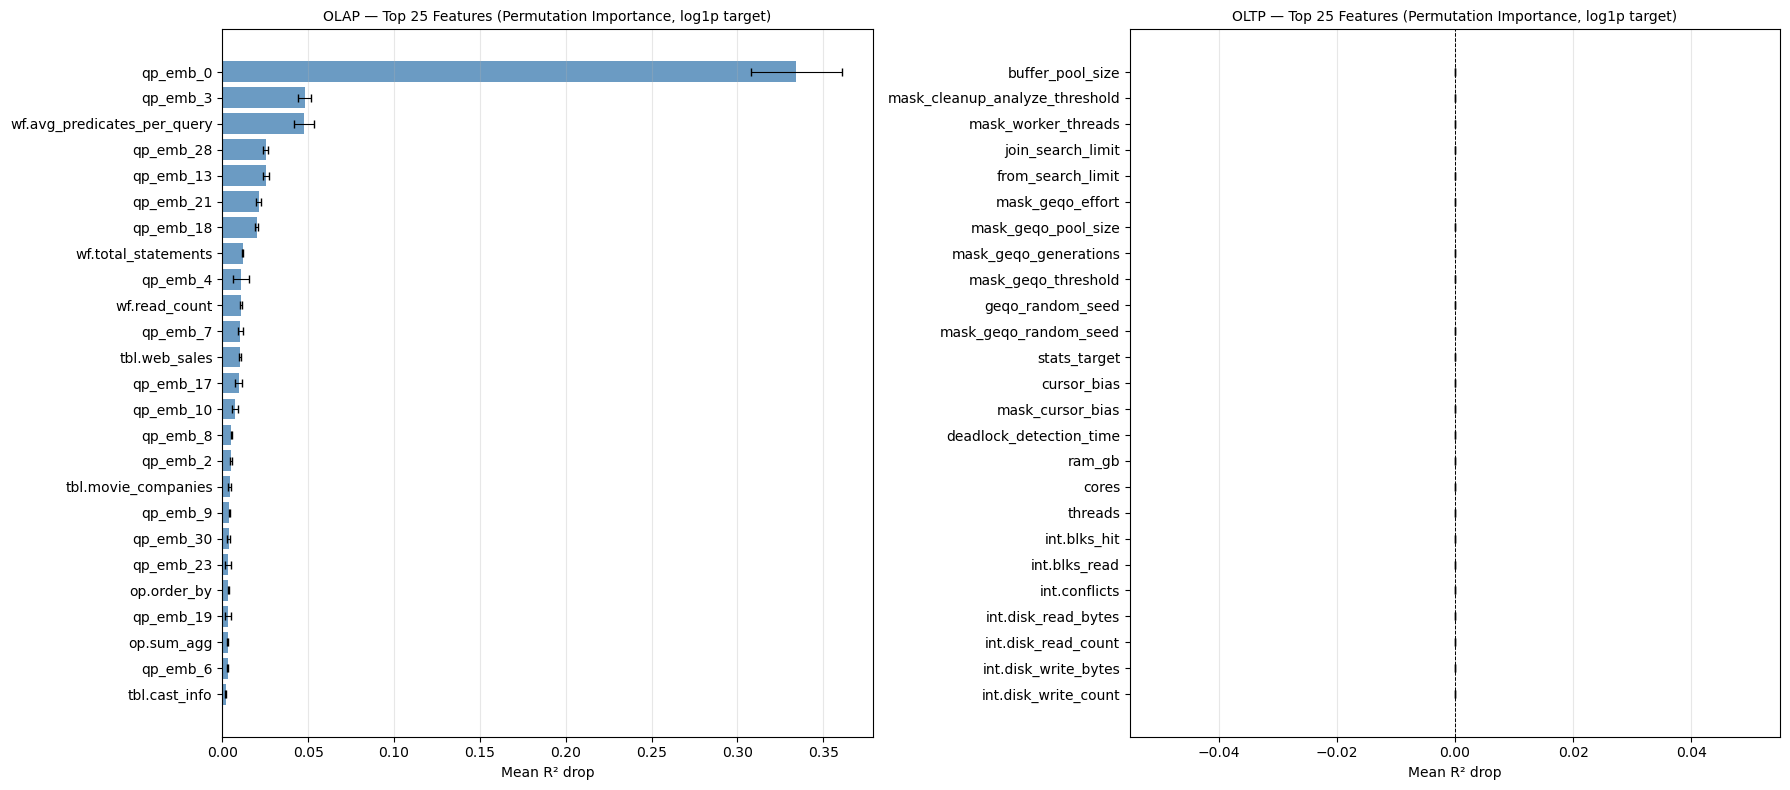

In [74]:
# ── Feature importance plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, wtype in zip(axes, ['OLAP', 'OLTP']):
    df_  = IMP_DFS[wtype].head(25)
    labels = [c.replace('collected.internal_metrics.', 'int.')
               .replace('collected.workload_features.operator_proportions.', 'op.')
               .replace('collected.workload_features.table_access_frequency.', 'tbl.')
               .replace('collected.workload_features.', 'wf.')
               for c in df_['feature']]
    ax.barh(labels[::-1], df_['importance'].values[::-1],
            xerr=df_['std'].values[::-1], color='steelblue', alpha=0.8,
            error_kw=dict(elinewidth=0.8, capsize=3))
    ax.set_title(f'{wtype} — Top 25 Features (Permutation Importance, log1p target)', fontsize=10)
    ax.set_xlabel('Mean R² drop')
    ax.axvline(0, color='k', lw=0.7, ls='--'); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance_olap_oltp.png', dpi=130, bbox_inches='tight')
plt.show()

## 11. Cross-Validation

Three model variants per workload type:
- **RF**: RandomForest on log1p(cost)
- **Ranker**: LGBMRanker (LambdaRank) — ranks within workload
- **Voting**: RF + LGBMRegressor (regression fallback for voting)

Note: VotingRegressor requires all sub-estimators to return numerical
predictions on the same scale. LGBMRanker outputs relevance scores
that are *not* on the log-cost scale, so we use **LGBMRegressor**
in the voting ensemble and LGBMRanker separately.

In [75]:
def rf_factory(workloads_tr=None):
    return RandomForestRegressor(
        n_estimators=500, max_depth=None, min_samples_leaf=3,
        max_features=0.4, bootstrap=True, n_jobs=-1, random_state=SEED)


def ranker_factory(workloads_tr):
    if LGBM_OK:
        return LGBMRankerWrapper(workloads_tr)
    else:
        # Fallback to GBM regressor
        from sklearn.ensemble import HistGradientBoostingRegressor
        class _W:
            def __init__(self): self.m = HistGradientBoostingRegressor(
                max_iter=500, learning_rate=0.05, max_depth=6,
                min_samples_leaf=10, l2_regularization=0.1,
                early_stopping=True, n_iter_no_change=20, random_state=SEED)
            def fit(self, X, y): self.m.fit(X, y); return self
            def predict(self, X, **kw): return self.m.predict(X)
        return _W()


def lgbm_reg_factory(workloads_tr=None):
    if LGBM_OK:
        return LGBMRegressor(
            n_estimators=500, learning_rate=0.05, num_leaves=63,
            min_child_samples=10, subsample=0.8, colsample_bytree=0.8,
            reg_lambda=0.1, random_state=SEED, n_jobs=-1, verbose=-1)
    else:
        from sklearn.ensemble import HistGradientBoostingRegressor
        return HistGradientBoostingRegressor(
            max_iter=500, learning_rate=0.05, max_depth=6,
            min_samples_leaf=10, l2_regularization=0.1,
            early_stopping=True, n_iter_no_change=20, random_state=SEED)


def voting_factory(workloads_tr=None):
    rf  = rf_factory()
    gbm = lgbm_reg_factory()
    # VotingRegressor needs sklearn-compatible estimators (not the ranker wrapper)
    return VotingRegressor(
        estimators=[('rf', rf), ('gbm', gbm)],
        weights=[1, 1], n_jobs=-1)


cv_rows = []

for wtype, tr, va, feats in [
    ('OLAP', olap_tr, olap_va, BEST_FEATS['OLAP']),
    ('OLTP', oltp_tr, oltp_va, BEST_FEATS['OLTP']),
]:
    tv = pd.concat([tr, va]).copy() if not va.empty else tr.copy()
    print(f'\n=== {wtype} CV ({len(tv)} rows, {tv["workload"].nunique()} workloads) ===')

    for name, factory in [
        ('RF',      rf_factory),
        ('Ranker',  ranker_factory),
        ('Voting',  voting_factory),
    ]:
        fd, summ = run_cv(factory, tv, feats, label=f'{wtype}_{name}')
        summ['wtype'] = wtype; summ['model'] = name
        cv_rows.append(summ)
        print(f'  {name:6s}  wl_sp={summ["wl_sp_mean"]:.4f}±{summ["wl_sp_std"]:.4f}  '
              f'sp={summ["sp_mean"]:.4f}  top3={summ["top3_mean"]:.4f}')
        print(f'         folds: {fd["wl_sp"].tolist()}')

cv_df = pd.DataFrame(cv_rows)
print('\n=== CV Summary ===')
print(cv_df[['wtype','model','wl_sp_mean','wl_sp_std','sp_mean','top3_mean']].to_string(index=False))


=== OLAP CV (7261 rows, 63 workloads) ===
  RF      wl_sp=0.8115±0.0939  sp=0.5953  top3=0.1001
         folds: [0.8325, 0.8556, 0.8594, 0.645, 0.8651]
  Ranker  wl_sp=-0.8130±0.0525  sp=-0.4350  top3=0.0918
         folds: [-0.7397, -0.8594, -0.825, -0.7802, -0.8607]
  Voting  wl_sp=0.6415±0.3726  sp=0.5527  top3=0.0989
         folds: [0.8325, -0.0042, 0.8691, 0.645, 0.8651]

=== OLTP CV (79 rows, 7 workloads) ===
  RF      wl_sp=nan±nan  sp=nan  top3=1.0000
         folds: [nan, nan, nan, nan, nan]
  Ranker  wl_sp=nan±nan  sp=nan  top3=1.0000
         folds: [nan, nan, nan, nan, nan]
  Voting  wl_sp=nan±nan  sp=nan  top3=1.0000
         folds: [nan, nan, nan, nan, nan]

=== CV Summary ===
wtype  model  wl_sp_mean  wl_sp_std  sp_mean  top3_mean
 OLAP     RF      0.8115     0.0939   0.5953     0.1001
 OLAP Ranker     -0.8130     0.0525  -0.4350     0.0918
 OLAP Voting      0.6415     0.3726   0.5527     0.0989
 OLTP     RF         NaN        NaN      NaN     1.0000
 OLTP Ranker      

## 12. Final Training on Train + Val

In [76]:
TRAINED = {}  # (wtype, model_name) -> (fitted_model, imputer, cols)

for wtype, tr, va, feats in [
    ('OLAP', olap_tr, olap_va, BEST_FEATS['OLAP']),
    ('OLTP', oltp_tr, oltp_va, BEST_FEATS['OLTP']),
]:
    tv   = pd.concat([tr, va]).copy() if not va.empty else tr.copy()
    cols = [c for c in feats if c in tv.columns]
    imp  = SimpleImputer(strategy='median')
    X_tv = imp.fit_transform(tv[cols])
    y_tv = tv['cost'].to_numpy(np.float64)   # log scale
    wl_tv = tv['workload'].to_numpy()

    print(f'\n{wtype} — {len(tv)} rows, {len(cols)} features')
    for name, factory in [
        ('RF',     rf_factory),
        ('Ranker', ranker_factory),
        ('Voting', voting_factory),
    ]:
        m = factory(wl_tv)
        m.fit(X_tv, y_tv)
        TRAINED[(wtype, name)] = (m, imp, cols)
        print(f'  {name} trained.')

print('\nAll models trained.')


OLAP — 7261 rows, 10 features
  RF trained.
  Ranker trained.
  Voting trained.

OLTP — 79 rows, 65 features
  RF trained.
  Ranker trained.
  Voting trained.

All models trained.


## 13. Held-Out Test Evaluation

Predictions are inverted from log-space (`expm1`) before metric computation.

In [77]:
test_results = []

for wtype, te in [('OLAP', olap_te), ('OLTP', oltp_te)]:
    y_raw  = te['cost_raw'].to_numpy(np.float64)
    wl_te  = te['workload'].to_numpy()
    ram_te = te['ram_gb'].to_numpy()

    print(f'\n=== {wtype} Test ({len(te)} rows, {te["workload"].nunique()} wls) ===')
    for name in ['RF', 'Ranker', 'Voting']:
        m, imp, cols = TRAINED[(wtype, name)]
        pred_log = m.predict(imp.transform(te[cols]))
        pred_raw = np.expm1(pred_log)   # back to original cost scale

        res = full_eval(y_raw, pred_raw, wl_te, ram=ram_te,
                         label=f'{wtype}_{name}')
        res['wtype'] = wtype; res['model'] = name
        test_results.append(res)

        flag = '  ✓' if res['wl_spearman_macro'] >= 0.70 else ''
        print(f'  {name:6s}  '
              f'wl_sp={res["wl_spearman_macro"]:.4f}  '
              f'wl_mean_sp={res["wl_mean_spearman"]:.4f}  '
              f'sp={res["overall_spearman"]:.4f}  '
              f'top3={res["top3_acc"]:.4f}  '
              f'mape={res["mape_pct"]:.1f}%  '
              f'n_wls={res["n_wls"]}{flag}')
        if 'subgroup' in res and not res['subgroup'].empty:
            for _, r in res['subgroup'].iterrows():
                print(f'    RAM {int(r.ram_gb)}GB: n={int(r.n)} '
                      f'sp={r.spearman} wl_sp={r.wl_spearman} top3={r.top3_acc}')


=== OLAP Test (2122 rows, 18 wls) ===
  RF      wl_sp=0.7173  wl_mean_sp=0.4634  sp=0.4984  top3=0.0703  mape=234.4%  n_wls=4  ✓
    RAM 32GB: n=602 sp=0.8975 wl_sp=0.866 top3=0.0698
    RAM 64GB: n=1520 sp=0.309 wl_sp=0.2899 top3=0.1286
  Ranker  wl_sp=-0.7235  wl_mean_sp=-0.3643  sp=-0.3038  top3=0.0571  mape=97.4%  n_wls=4
    RAM 32GB: n=602 sp=-0.6051 wl_sp=-0.866 top3=0.0
    RAM 64GB: n=1520 sp=-0.189 wl_sp=-0.2899 top3=0.1268
  Voting  wl_sp=0.7173  wl_mean_sp=0.4964  sp=0.5134  top3=0.0703  mape=238.0%  n_wls=4  ✓
    RAM 32GB: n=602 sp=0.8975 wl_sp=0.866 top3=0.0698
    RAM 64GB: n=1520 sp=0.3533 wl_sp=0.2899 top3=0.1286

=== OLTP Test (23 rows, 2 wls) ===
  RF      wl_sp=nan  wl_mean_sp=nan  sp=nan  top3=1.0000  mape=nan%  n_wls=0
    RAM 64GB: n=23 sp=nan wl_sp=nan top3=1.0
  Ranker  wl_sp=nan  wl_mean_sp=nan  sp=nan  top3=1.0000  mape=nan%  n_wls=0
    RAM 64GB: n=23 sp=nan wl_sp=nan top3=1.0
  Voting  wl_sp=nan  wl_mean_sp=nan  sp=nan  top3=1.0000  mape=nan%  n_wls=0
   

## 14. Summary Table

In [78]:
summary = pd.DataFrame([{
    'wtype':          r['wtype'],
    'model':          r['model'],
    'wl_sp_macro':    r['wl_spearman_macro'],
    'wl_mean_sp':     r.get('wl_mean_spearman', float('nan')),
    'overall_sp':     r['overall_spearman'],
    'top3_acc':       r['top3_acc'],
    'mape_pct':       r['mape_pct'],
    'n_wls':          r['n_wls'],
} for r in test_results])

print('=== FULL RESULTS ===')
print(summary.to_string(index=False))

print('\n=== BEST MODEL PER WORKLOAD TYPE ===')
best = summary.loc[summary.groupby('wtype')['wl_sp_macro'].idxmax()]
print(best[['wtype','model','wl_sp_macro','wl_mean_sp','overall_sp','top3_acc','mape_pct']].to_string(index=False))

print('\nTargets:')
for _, r in best.iterrows():
    target = 0.80 if r['wtype']=='OLAP' else 0.70
    s = '✓ ACHIEVED' if r['wl_sp_macro'] >= target else f'✗  gap={target - r["wl_sp_macro"]:.4f}'
    print(f'  {r["wtype"]:4s} [{r["model"]:6s}]: {r["wl_sp_macro"]:.4f}  (target>={target})  {s}')

=== FULL RESULTS ===
wtype  model  wl_sp_macro  wl_mean_sp  overall_sp  top3_acc  mape_pct  n_wls
 OLAP     RF       0.7173      0.4634      0.4984    0.0703    234.38      4
 OLAP Ranker      -0.7235     -0.3643     -0.3038    0.0571     97.37      4
 OLAP Voting       0.7173      0.4964      0.5134    0.0703    238.01      4
 OLTP     RF          NaN         NaN         NaN    1.0000       NaN      0
 OLTP Ranker          NaN         NaN         NaN    1.0000       NaN      0
 OLTP Voting          NaN         NaN         NaN    1.0000       NaN      0

=== BEST MODEL PER WORKLOAD TYPE ===


KeyError: '[nan] not in index'

## 15. Visualizations

In [ ]:
# ── Plot 1: Log vs Raw cost distribution ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for row_ax, wtype, df_ in zip(axes, ['OLAP','OLTP'], [olap_df, oltp_df]):
    for ax, col, title in zip(row_ax, ['cost_raw', 'cost'],
                               [f'{wtype} Raw Cost', f'{wtype} log1p(Cost)']):
        ax.hist(df_[col].values, bins=60, color='steelblue', alpha=0.7, edgecolor='none')
        ax.set_title(title); ax.set_xlabel(col); ax.grid(alpha=0.3)
plt.suptitle('Effect of log1p transform on cost distribution', fontsize=11)
plt.tight_layout()
plt.savefig('log_transform_effect.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Plot 2: CV vs Test ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, wtype in zip(axes, ['OLAP', 'OLTP']):
    models  = ['RF', 'Ranker', 'Voting']
    x, w    = np.arange(len(models)), 0.35
    cv_sub  = cv_df[cv_df['wtype']==wtype]
    te_sub  = summary[summary['wtype']==wtype]
    cv_m    = [cv_sub[cv_sub['model']==m]['wl_sp_mean'].values[0] for m in models]
    cv_s    = [cv_sub[cv_sub['model']==m]['wl_sp_std'].values[0]  for m in models]
    te_m    = [te_sub[te_sub['model']==m]['wl_sp_macro'].values[0] for m in models]
    ax.bar(x-w/2, cv_m, w, yerr=cv_s, label='CV', color='steelblue', alpha=0.8, capsize=5)
    ax.bar(x+w/2, te_m, w, label='Test', color='coral', alpha=0.8)
    target = 0.80 if wtype=='OLAP' else 0.70
    ax.axhline(target, color='green', ls='--', lw=1.2, label=f'Target {target}')
    ax.set_xticks(x); ax.set_xticklabels(models)
    ax.set_ylabel('WL Spearman Macro'); ax.set_ylim(0, 1)
    ax.set_title(f'{wtype} — CV vs Test'); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cv_vs_test.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Plot 3: Per-workload Spearman histograms ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, wtype, te in zip(axes, ['OLAP','OLTP'], [olap_te, oltp_te]):
    m, imp, cols = TRAINED[(wtype, 'Voting')]
    pred_raw = np.expm1(m.predict(imp.transform(te[cols])))
    y_raw    = te['cost_raw'].to_numpy(); wl_te = te['workload'].to_numpy()
    sps = [safe_spearman(y_raw[wl_te==w], pred_raw[wl_te==w])
            for w in np.unique(wl_te) if (wl_te==w).sum()>=3]
    sps = [s for s in sps if not np.isnan(s)]
    ax.hist(sps, bins=20, color='steelblue', alpha=0.8, edgecolor='white')
    ax.axvline(np.mean(sps), color='red', ls='--', label=f'Mean={np.mean(sps):.3f}')
    target = 0.80 if wtype=='OLAP' else 0.70
    ax.axvline(target, color='green', ls=':', lw=1.5, label=f'Target {target}')
    ax.set_xlabel('Per-Workload Spearman'); ax.set_ylabel('Count')
    ax.set_title(f'{wtype} Voting — Per-Workload Spearman ({len(sps)} wls)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('per_workload_spearman.png', dpi=130, bbox_inches='tight')
plt.show()

## 16. Per-Workload Breakdown (Voting — Test)

In [ ]:
for wtype, te in [('OLAP', olap_te), ('OLTP', oltp_te)]:
    m, imp, cols = TRAINED[(wtype, 'Voting')]
    pred_raw = np.expm1(m.predict(imp.transform(te[cols])))
    y_raw    = te['cost_raw'].to_numpy()
    wl_te    = te['workload'].to_numpy()

    rows = []
    for w in np.unique(wl_te):
        mask = wl_te == w
        rows.append(dict(
            workload = w,
            n        = int(mask.sum()),
            spearman = round(safe_spearman(y_raw[mask], pred_raw[mask]), 4),
            pred_std = round(float(pred_raw[mask].std()), 4),
            true_std = round(float(y_raw[mask].std()),    4),
            top3_acc = round(top_k_acc(y_raw[mask], pred_raw[mask],
                                        np.full(mask.sum(), w)), 4),
        ))

    wl_df = pd.DataFrame(rows).sort_values('spearman', ascending=False)
    print(f'\n=== {wtype} — Per-Workload Breakdown (Voting) ===')
    print(wl_df.to_string(index=False))
    low = (wl_df[wl_df['n']>=3]['pred_std'] < 0.05).sum()
    if low: print(f'  WARNING: {low} workloads with near-zero pred_std (model not discriminating)')